# STOPP


In [15]:
import pickle

with open(r"C:\Users\victo\Downloads\SB_lab\TestFlow\rotations\0_u_v.pkl", 'rb') as f:
    unpickler = pickle.Unpickler(f)  # Remove weights_only if present
    obj = unpickler.load()

In [16]:
import torch
print(torch.__version__)

2.6.0+cu126


In [1]:
from cellpose.io import imread
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import gaussian_filter
from scipy import spatial
from sklearn.neighbors import KDTree
from scipy.stats import circmean
import os
import sys, time,random
from pathlib import Path
from PIL import Image
from joblib import Parallel, delayed
import h5py
from skimage.measure import label, regionprops
import seaborn as sns


sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 


In [8]:
# path = r"E:\HT1080\c3_6well_5min_10x\_4\Pos10"  
# path = r"E:\C2C12 and RPE in 6 well\15min5x\_1\Pos2"
# path = r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6 Wells _5x_15min\_1\Pos0"
# path = r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\60X_singles"
# path = r"E:\C2C12 and RPE in 6 well\15min5x\_1\Pos20"
# path = r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6Wells_5X_15min_CK666\_1\Pos30"
# path = r"C:\Users\victo\OneDrive - BGU\BEER\6"
path = r"C:\Users\victo\Downloads\frames_from_video\reverse_5_elong_1_5_run_dev_1"

image_list = glob.glob(os.path.join(path, '*.tif')) + glob.glob(os.path.join(path, '*.png')) 
image_list = natsorted(image_list, key=lambda y: y.lower())
# img = cv2.imread(image_list[0])[:,:,0]
# analyze_defects(img, sigma=21)


 ## Test Flow and Nematics

In [9]:
%matplotlib qt
# im_num = 120
# flow_sigma = 15
# ori_sigma = 21
# fig,(ax1, ax2) = plt.subplots(1,2,  figsize=(16,8))

def plot_flow_and_nematics(image_list, im_num, axs=None, flow_sigma=15, ori_sigma=21):
    width = -1
    img1 = cv2.imread(image_list[im_num])[:, :width,0]
    img2 = cv2.imread(image_list[im_num+1])[:, :width,0]
    flow = cv2.calcOpticalFlowFarneback(img1,img2, None, 0.5, 3, 
        winsize=flow_sigma, iterations=3, poly_n=5, poly_sigma=1.2, flags=0) 
    flow[..., 0] = flow[..., 0]- np.mean(flow[..., 0])
    flow[..., 1] = flow[..., 1]- np.mean(flow[..., 1])

    step = int(flow_sigma*1.)

    if axs is None:
        fig, axs = plt.subplots(1,2,  figsize=(16,8))
    
    axs[0].axis('off'); axs[1].axis('off')   
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_clahe = clahe.apply(img1)
    axs[0].imshow(255-img_clahe, cmap="gray")  
    axs[0].set_title(image_list[im_num])
    

    y, x = np.mgrid[0:img1.shape[0], 0:img1.shape[1]]
    axs[0].quiver(x[::step, ::step], y[::step, ::step], 
            flow[::step, ::step, 0], -flow[::step, ::step, 1], 
            color="red", scale=80, alpha=.5, width=.005)


    ori, plus, min = analyze_defects(img1, sigma=ori_sigma)

    s = int(flow_sigma*1)
    # axs[1].imshow(np.zeros_like(img1, dtype=np.float32), cmap="gray")
    axs[1].imshow(255-img_clahe, cmap="gray")


    quiver = axs[1].quiver(x[::s,::s], y[::s,::s],
        np.cos(ori)[::s,::s], np.sin(ori)[::s,::s], np.arctan2(np.sin(ori), np.cos(ori))[::s,::s],
        headaxislength=0, headwidth=0, headlength=0, width=.005, 
        scale=60, pivot='mid', alpha=.5, cmap="hsv")

    alpha_half, scale_half = .8, 15    
    axs[1].plot(plus['x'], plus['y'],'ro',markersize=8, alpha=alpha_half)
    axs[1].quiver(plus['x'], plus['y'], 
        np.cos(plus['ang1']), -np.sin(plus['ang1']), 
        headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

    axs[1].plot(min['x'], min['y'],'o',markersize=6, alpha=alpha_half, color='dodgerblue')
    for j in range(3):
        axs[1].quiver(min['x'], min['y'], 
            np.cos(min['ang'+str(j+1)]), -np.sin(min['ang'+str(j+1)]), 
            headaxislength=0, headwidth=0, headlength=0, color='dodgerblue', scale=scale_half, alpha=alpha_half)

# fig,(ax1, ax2) = plt.subplots(1,2,  figsize=(20,10))
path = r"C:\Users\victo\Downloads\Test01"
for i in range(34,200,2):
    # ax1.cla()
    # ax2.cla()    
    # plot_flow_and_nematics(image_list, i, axs=(ax1, ax2), flow_sigma=15, ori_sigma=31)
    # os.makedirs(path, exist_ok=True)
    # fig.savefig(path + r"\flow_and_nematics_" + str(i) + ".png", dpi=100, bbox_inches='tight')
    plot_flow_and_nematics(image_list, i, flow_sigma=15, ori_sigma=7)
    break

In [21]:
first_frame = 30
last_frame = 150 #len(image_list)
df_list = Parallel(n_jobs=5)(delayed(lambda img: analyze_defects(img, sigma=21))
    (
    cv2.imread(img)[:,:,0]
    ) for img in image_list[first_frame:last_frame-1])

for i, df in enumerate(df_list):
    df[1]['frame'] = i
    df[2]['frame'] = i

# Concatenate the DataFrames
df_plus = pd.concat([df[1] for df in df_list], ignore_index=True)
df_minus = pd.concat([df[2] for df in df_list], ignore_index=True)

In [22]:
%matplotlib inline
df_plus.groupby('frame').size().plot(linewidth=3, alpha=.5, color="r")
df_minus.groupby('frame').size().plot(linewidth=3, alpha=.5, color="b")

plt.xlabel("$Frame$", fontsize=15)
plt.ylabel("$Number ~of ~defects$", fontsize=15)

# TODO add tracking of defects and detect pairs

Text(0, 0.5, '$Number ~of ~defects$')

# VRMS

In [2]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import gaussian_filter
import os
import sys, time,random
from pathlib import Path
from joblib import Parallel, delayed


sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 

# first_frame = 0
# last_frame = len(image_list)

def uv_list(img1, img2, sigma=15, resize=None):
    '''Works for 8-bit and 16-bit images'''
    if img1.dtype != np.uint8:
        img1 = cv2.normalize(img1, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    if img2.dtype != np.uint8:
        img2 = cv2.normalize(img2, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    if resize:
        img1 = cv2.resize(img1, (img1.shape[1]//resize, img1.shape[0]//resize), interpolation=cv2.INTER_AREA)
        img2 = cv2.resize(img2, (img2.shape[1]//resize, img2.shape[0]//resize), interpolation=cv2.INTER_AREA)
        
    flow = cv2.calcOpticalFlowFarneback(
        img1, img2, None, 0.5, 3, 
        winsize=sigma, iterations=3, poly_n=5, poly_sigma=1.2, flags=0) 
    flow[..., 0] = flow[..., 0]- np.mean(flow[..., 0])
    flow[..., 1] = flow[..., 1]- np.mean(flow[..., 1])
    return flow[..., 0], flow[..., 1]

def compute_uv(image_list, sigma=15, resize=None):
    vel_list = Parallel(n_jobs=4)(delayed(uv_list)(
        cv2.imread(img1, cv2.IMREAD_UNCHANGED),
        cv2.imread(img2, cv2.IMREAD_UNCHANGED),
        sigma=sigma,
        resize=resize
        ) for (img1,img2) in zip(image_list[:-1], image_list[1:]))
    u = [vel[0] for vel in vel_list]
    v = [vel[1] for vel in vel_list]
    return u, v

## VRMS for floder with images (One FOV)

Text(0.5, 1.0, 'Hacat-Pos1 | N:188')

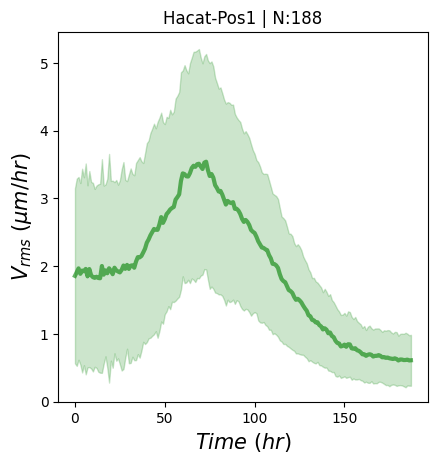

In [128]:
# test time evolution of velocity
%matplotlib inline
sigma = 15
resize = 2
# image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\HBEC\s2(120-1057)\Raw\*.tif"); sigma = 15
# image_list = glob.glob(r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\OFdata\40x Phase Contrast (Inside)\*.tif")
# image_list = glob.glob(r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\ISF defects new\6\*.tif")
# image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\DATA\C2C12 and RPE in 6 well\C2C12_RPE1_15min5x\_1\*\*.tif")
# image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6 Wells _5x_15min\_1\Pos0\*.tif")
# image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\DATA\HT1080\HT1080_5x_5_min_24_well_media_DMSO_C3\_2\Pos41\*.tif")
# image_list = glob.glob(r"E:\Hacat\6 Wells _5x_15min\_3\Pos0\*.tif")
image_list = glob.glob(r"D:\Hacat\6Wells_5X_15min_CK666\_1\Pos1\*.tif")
# image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6Wells_5X_15min_Starvation_added_Serum\_1\Pos13\*.tif")
image_list = natsorted(image_list, key=lambda y: y.lower())

u, v = compute_uv(image_list[:], sigma=sigma, resize=resize)

fph = 1
px = .9 *2
vrms = np.array([np.mean((uu**2 + vv**2)**.5) for (uu,vv) in zip(u,v)])
std = np.array([np.std((uu**2 + vv**2)**.5) for (uu,vv) in zip(u,v)])

plt.plot(np.arange(len(vrms))/fph, vrms*px*fph, "g", linewidth=3, alpha=.6)
plt.fill_between(np.arange(len(vrms))/fph, (vrms-std)*px*fph, (vrms+std)*px*fph, color="g", alpha=.2)
plt.xlabel("$Time ~(hr)$", fontsize=15)
plt.ylabel("$V_{rms} ~(\mu m/hr)$", fontsize=15)
plt.gca().set_box_aspect(1)
plt.ylim(0, None)
plt.title("-".join([Path(image_list[0]).parts[i] for i in (1, -2)])+ " | N:" +str(len(u)))

### Plot a frame

In [126]:
%matplotlib qt
im_img = 80
resize = 3
img1 = cv2.imread(image_list[im_img], cv2.IMREAD_UNCHANGED)
img2 = cv2.imread(image_list[im_img+1], cv2.IMREAD_UNCHANGED)

if resize is not None:
    img1 = cv2.resize(img1, (img1.shape[1]//resize, img1.shape[0]//resize), interpolation=cv2.INTER_AREA)
    img2 = cv2.resize(img2, (img2.shape[1]//resize, img2.shape[0]//resize), interpolation=cv2.INTER_AREA)
# plt.imshow(img1, cmap="gray")
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4,4))
img_clahe = clahe.apply(img1)
plt.imshow(img_clahe.max()-img_clahe, cmap="gray")  
plt.title(str(Path(image_list[im_img]).parents[2].name) + "\n " + str(Path(image_list[im_img]).name))

for color,sigma in zip(["r","g"], (15, 25)):
        uu,vv = uv_list(img1, img2, sigma=15)

        step = 11#int(2*sigma)
        y, x = np.mgrid[0:u[0].shape[0], 0:u[0].shape[1]]
        plt.quiver(x[::step, ::step], y[::step, ::step], 
                u[0][::step, ::step], -v[0][::step, ::step], 
                color=color, scale=sigma*2, alpha=.6, width=.005)


In [3]:
st

NameError: name 'st' is not defined

## Multiple  FOVs

In [ ]:
folder = r"D:\Hacat\6Wells_5X_15min_CK666\_1"

first_fov, last_fov = 3, 41
exclude_list = [6,13,20,27,34]
fov_lst = np.array([fov for fov in np.arange(first_fov, last_fov) if fov not in exclude_list])

fph = 4
px = 1.8

for i, fov in enumerate(fov_lst):
    image_list = natsorted(glob.glob(folder + "/Pos" + str(fov) + "\*.tif"), key=lambda y: y.lower())
    if len(image_list) < 2:
        continue

    u, v = compute_uv(image_list)
    vrms = np.array([np.mean((uu**2 + vv**2)**.5) for (uu, vv) in zip(u, v)])
    std = np.array([np.std((uu**2 + vv**2)**.5) for (uu, vv) in zip(u, v)])

    plt.figure()
    plt.plot(np.arange(len(vrms)) / fph, vrms * px * fph, "g", linewidth=3, alpha=.6)
    plt.fill_between(np.arange(len(vrms)) / fph, (vrms - std) * px * fph, (vrms + std) * px * fph, color="g", alpha=.2)
    plt.xlabel("$Time ~(hr)$", fontsize=15)
    plt.ylabel("$V_{rms} ~(\mu m/hr)$", fontsize=15)
    plt.gca().set_box_aspect(1)
    plt.ylim(0, None)
    plt.title(f"FOV: Pos{fov}")

    save_base = Path(folder) / f"Pos{fov}"
    plt.savefig(str(save_base) + "_vrms.png")
    plt.close()

    pd.DataFrame({'vrms': vrms, 'std': std}).to_csv(str(save_base) + "_vrms.csv", index=False)

In [ ]:
for i in range(len(u)):
    print(vel_list[1][0].shape, vel_list[1][1].shape)
# 

In [ ]:
folder = os.path.join(
    str(Path(image_list[0]).parents[0]), 
    'OptFlow_csv')
print(folder)
os.makedirs(folder, exist_ok=True)

C:\Users\victo\OneDrive - BGU\HBEC\s2(120-1057)\OptFlow_csv


In [ ]:
# SAVE u and v as CSV files (for Gil)
for (i, (u_i, v_i)) in enumerate(zip(u, v)):
    ii = first_frame + i
    pd.DataFrame(u_i.astype(np.float16)).to_csv(folder + "/u_"+str(ii)+".csv", index=False)
    pd.DataFrame(v_i.astype(np.float16)).to_csv(folder + "/v_"+str(ii)+".csv", index=False)    

In [ ]:
# test frame
%matplotlib qt
i = 5
step = 15 
first_frame = 0

fig = plt.figure(figsize=(10,10))

img = cv2.imread(image_list[first_frame+i])[:,:,0]
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img)
plt.imshow(255-img_clahe, cmap="gray")

flow = np.stack((u[first_frame+i], v[first_frame+i]), axis=-1)

x = np.arange(0, flow.shape[1], step, dtype=np.int16)
y = np.arange(0, flow.shape[0], step, dtype=np.int16)
plt.quiver(x,y, 
    flow[::step, ::step, 0], -flow[::step, ::step, 1], 
    color="red", scale=50, label="flow", alpha=.5)
plt.title(image_list[first_frame+i])


# image_list

Text(0.5, 1.0, 'C:\\Users\\victo\\OneDrive - BGU\\DATA\\Hacat\\6Wells_5X_15min_Starvation_added_Serum\\_1\\Pos13\\img_channel000_position013_time000000005_z000.tif')

In [ ]:
# Save the velocities as npy files
folder = os.path.join(
    str(Path(image_list[0]).parents[0]), 
    'OptFlow')
print(folder)
os.makedirs(folder, exist_ok=True)

for i in range(len(vel_list)):
    # print("Saving velocities for frame {}".format(i))
    
    save_path = folder + r"\{}.npy".format(first_frame+i)
    # os.makedirs(os.path.dirname(folder), exist_ok=True)
    
    np.save(
        save_path,
        np.stack((vel_list[i][0], vel_list[i][1]), axis=-1).astype(np.float16),
    )
    # break

C:\Users\victo\OneDrive - BGU\DATA\HT1080\HT1080_5x_5_min_24_well_media_DMSO_C3\_2\Pos41\OptFlow


In [ ]:
%matplotlib inline
img_num = 70

i = first_frame+img_num
step = 15 

fig = plt.figure(figsize=(10,10))

save_path = folder + r"\{}.npy".format(i)
flow = np.load(save_path)
img = cv2.imread(image_list[i])[:,:,0]
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img)
plt.imshow(255-img_clahe, cmap="gray")
x = np.arange(0, flow.shape[1], step, dtype=np.int16)
y = np.arange(0, flow.shape[0], step, dtype=np.int16)
plt.quiver(x,y, 
    flow[::step, ::step, 0], -flow[::step, ::step, 1], 
    color="red", scale=100, label="flow", alpha=.5)
plt.title(image_list[i])

## Flow on Defects

In [14]:
# image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6Wells_5X_15min_CK666\_1\Pos3\*.tif")
# image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6 Wells _5x_15min\_1\Pos0\*.tif")
# image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6Wells_5X_15min_Starvation_added_Serum\_1\Pos13\*.tif")
image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\HBEC\s2(120-1057)\Raw\*.tif")
# image_list = glob.glob(r"D:\Hacat\6Wells_5X_15min_CK666\_1\Pos1\*.tif")
image_list = natsorted(image_list, key=lambda y: y.lower())

first_frame = 200
last_frame = 220 #len(image_list)
box = 400

# NOTICE MINUS analyze_defects(img1, sigma=ori_sigma)[2] is calculated now!

ori_sigma = 26 #11
flow_sigma = 15 #15

images = [cv2.imread(img, cv2.IMREAD_UNCHANGED) for img in image_list[first_frame:last_frame]]


u_v_count = Parallel(n_jobs=5)(delayed(defect_flow_frame_average_with_edge)(
    img1, img2, 
    analyze_defects(img1, sigma=ori_sigma)[2][['x','y','ang1']].rename(columns={"x":"xp", "y":"yp", "ang1":"angp1"}),
    defect_type="all", 
    box=(int(box),int(box)),
    filt=1,
    sigma=flow_sigma,
    # vorticity="right",
    ) for img1,img2 in zip(images[:-1], images[1:]))

In [15]:
print(image_list[first_frame])
print(image_list[last_frame])

C:\Users\victo\OneDrive - BGU\HBEC\s2(120-1057)\Raw\Trans__200.tif
C:\Users\victo\OneDrive - BGU\HBEC\s2(120-1057)\Raw\Trans__220.tif


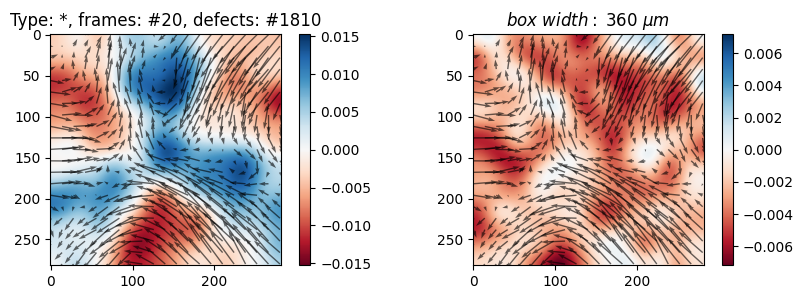

In [ ]:
%matplotlib inline
u, v, count = [], [], []
for q in u_v_count:
    if q:
        u.append(q[0])
        v.append(q[1])
        count.append(q[2])
u = np.array(u)
v = np.array(v)
count = np.array(count)  

n, m = 0,-1 
u_up = np.average(u[count!= 0][n:m,:,:], axis=0, weights=count[count!= 0][n:m])
v_up = np.average(v[count!= 0][n:m,:,:], axis=0, weights=count[count!= 0][n:m])

filt = 15
step = u_up.shape[0]//20
vscale = 4

fig, axs = plt.subplots(1,2, figsize=(10,3))
# for ax in axs.ravel(): ax.axis('off')
ax1, ax2 = axs.ravel()

field = np.stack((u_up, v_up), axis=-1)
y, x = np.mgrid[0:u_up.shape[0], 0:u_up.shape[1]] 
vorticity = gaussian_filter(def(field), sigma=filt)
vort_scale = np.max([np.max(vorticity), -np.min(vorticity)])
c1 = ax1.imshow(vorticity, cmap='RdBu', vmin=-vort_scale, vmax=vort_scale)
ax1.quiver(x[::step, ::step], y[::step, ::step], 
          u_up[::step, ::step], -v_up[::step, ::step],  color='k',
          width=.006, scale=vscale, alpha=.6)
ax1.set_title("Type: %1s, frames: #%1d, defects: #%1d" % ("*", last_frame-first_frame, np.sum(count)))
fig.colorbar(c1)

divergence = gaussian_filter(divergence_npgrad(field), sigma=filt)
div_scale = np.max([np.max(divergence), -np.min(divergence)])
c2 = ax2.imshow(divergence, cmap='RdBu', vmin=-div_scale, vmax=div_scale)
ax2.quiver(x[::step, ::step], y[::step, ::step], 
          u_up[::step, ::step], -v_up[::step, ::step],  color='k',
          width=.006, scale=vscale, alpha=.6)
ax2.set_title("$box ~width: ~%1d ~\mu m$" % (box * .9))
fig.colorbar(c2)

In [17]:
st

NameError: name 'st' is not defined

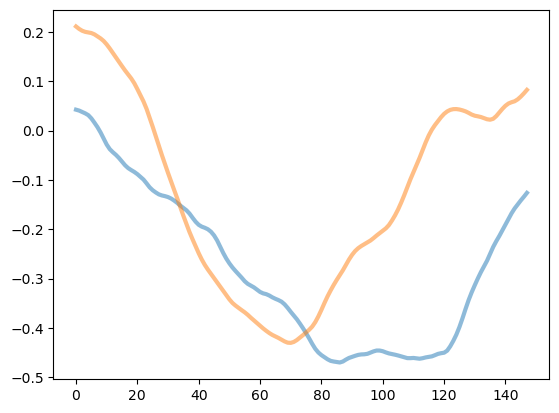

In [ ]:
midlle = u_up.shape[1]//2
plt.plot(u_up[midlle-10:midlle+10,:].mean(axis=0), linewidth=3, alpha=.5)
plt.plot(u_up[:,midlle-10:midlle+10].mean(axis=1), linewidth=3, alpha=.5)

In [ ]:
u_up.max()*1.8*4, u_up.min()

(2.7106034421389427, -0.039223903227850604)

## Defects motion from csv table

In [63]:
output_csv = r"C:\Users\victo\OneDrive - BGU\HBEC\s2(120-1057)\Nematics\PlusAndMinusTM_Raw_frame160_500_sigma21.csv"

all_pairs_df = pd.read_csv(output_csv).dropna(subset=["TRACK_ID"])


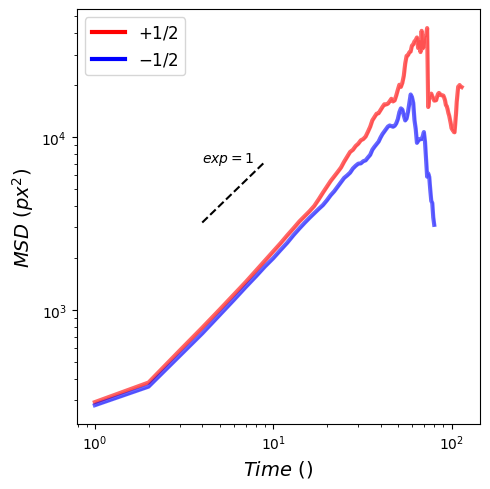

In [51]:
min_dist, max_dist = 40, 40
min_track = 1

df = all_pairs_df.copy()
plus_ = msd_from_df(df[df.charge==0.5],"x_img1","y_img1","FRAME","TRACK_ID",minimal_track=min_track)
minus_ = msd_from_df(df[df.charge==-0.5],"x_img1","y_img1","FRAME","TRACK_ID",minimal_track=min_track)


%matplotlib inline
fig, ax1 = plt.subplots(1,1, figsize=(5,5))

win = 1

colors = ["-r", "-b"]

for msd_df,color in zip([plus_, minus_], colors):
    msd_df = msd_df.sort_values(by="FRAME")
    msd_df["ave"] = roll_func(msd_df.MSD, msd_df.FRAME, win, func=np.mean)
    msd_df["std"] = roll_func(msd_df.MSD, msd_df.FRAME, win, func=np.std)
    msd_df["count"] = roll_func(msd_df.MSD, msd_df.FRAME, win, np.sum)

    ax1.plot(msd_df.FRAME, msd_df["ave"], color, alpha=.6, linewidth=3)
    ax1.fill_between(msd_df.FRAME, 
                    msd_df["ave"]-msd_df["std"]/msd_df["count"]**.5, 
                    msd_df["ave"]+msd_df["std"]/msd_df["count"]**.5, 
                    color=''.join(x for x in color if x.isalpha()), alpha=.2) 


ax1.plot([0,0],[0,0], "-", color="r", linewidth=3, label=r"$+1/2$")
ax1.plot([0,0],[0,0], "-", color="b", linewidth=3, label=r"$-1/2$")
xref = np.arange(4, 10, 1)
ax1.plot(xref, 8e2*xref**1,"--k")
ax1.text(xref[0], 8e2*xref[-1]**1, r"$exp=1$")
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel(r"$Time ~()$", fontsize=14); ax1.set_ylabel(r"$MSD ~(px^2)$", fontsize=14)
plt.legend(loc='upper left', fontsize=12); plt.tight_layout()


In [66]:
df = all_pairs_df.copy()
df.rename(columns={
                    'x_img':'x', 'y_img':'y',
                    'FRAME':'frame', 'TRACK_ID':'particle',
                    }, inplace=True)

Text(0.5, 1.0, 'PlusAndMinusTM_2_frame0_-1_sigma11_step1.csv')

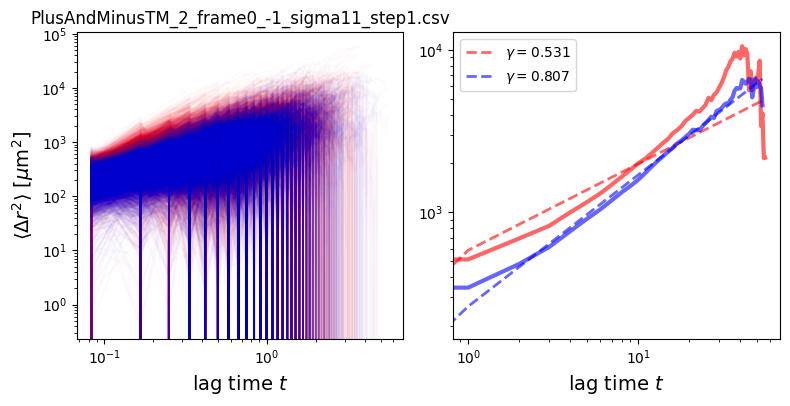

In [2]:
from scipy.optimize import curve_fit
import trackpy as tp
# Define a power law function for fitting
def power_law(x, a, b):
    return a * x**b


# output_csv = r"C:\Users\victo\OneDrive - BGU\HBEC\s2(120-1057)\Nematics\PlusAndMinusTM_Raw_frame160_500_sigma21.csv"
# output_csv = r"C:\Users\victo\OneDrive - BGU\BEER\Nematics\PlusAndMinusTM_6_frame0_-1_sigma15_step1.csv"
# output_csv = r"C:\Users\victo\Downloads\Nematics\PlusAndMinusTM_tubulin_frame1_-1_sigma25_step2.csv"
output_csv = r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\real ccw\Nematics\PlusAndMinusTM_2_frame0_-1_sigma11_step1.csv"

all_pairs_df = pd.read_csv(output_csv).dropna(subset=["TRACK_ID"])

  
df = all_pairs_df.copy()
df.rename(columns={
                    'x_img':'x', 'y_img':'y',
                    'FRAME':'frame', 'TRACK_ID':'particle',
                    }, inplace=True)

px_size = 0.645
frames_per_hour = 12
track_len = 5

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(8, 4))
# tm = tp.filter_stubs(df[df.charge==0.5], 5)
trajectories = [tp.filter_stubs(df[df.charge==0.5], track_len), 
                tp.filter_stubs(df[df.charge==-0.5], track_len)]

for color,traj in zip(["r","b"], trajectories):
    im = tp.imsd(traj, px_size, frames_per_hour)  # microns per pixel = 100/285., frames per hour = 24

    em = tp.emsd(traj, px_size, frames_per_hour) 
    # drop last values noisy MSDs   
    em = em.iloc[:-10].reset_index(drop=True)

    # fit a power law function
    weights = em**1
    params, covariance = curve_fit(power_law, em.index, em, sigma=weights)
    
    ax1.plot(im.index, im, color, alpha=0.02)  # black lines, semitransparent
    ax2.plot(em.index, em, color, linewidth=3, alpha=0.6)
    ax2.plot(em.index, power_law(em.index, *params), color=color, linestyle="--", linewidth=2, alpha=0.6, label="$\gamma=%.5s$" % params[1])
    # ax2.plot(em.index, power_law(em.index, *[320,   1.11]), "--k", linewidth=3, alpha=0.6, label="$\gamma=%.5s$" % 1.11)

ax1.set_ylabel(r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]', fontsize=14)

for ax in [ax1, ax2]:    
    ax.set_xlabel('lag time $t$', fontsize=14)
    ax.set_xscale('log')
    ax.set_yscale('log')
plt.tight_layout()
plt.legend()
ax1.set_title(Path(output_csv).name)

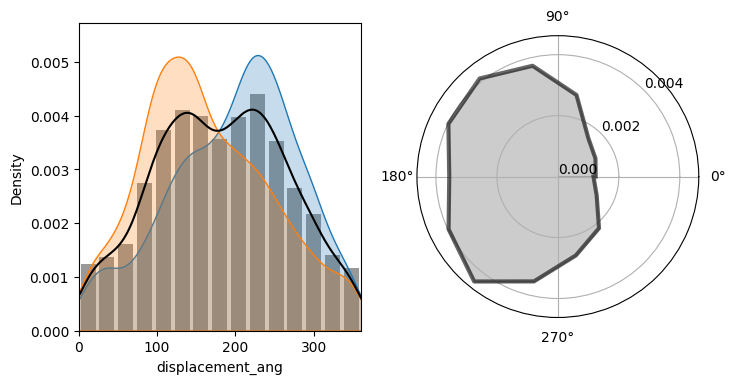

In [50]:
# -------------------------------------FOR UNPAIRED--------
# output_csv = r"C:\Users\victo\OneDrive - BGU\HBEC\s2(120-1057)\Nematics\PlusAndMinusTM_Raw_frame160_500_sigma21.csv"
# # output_csv = r"C:\Users\victo\OneDrive - BGU\BEER\Nematics\PlusAndMinusTM_6_frame0_-1_sigma15_step1.csv"
# # output_csv = r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\real ccw\Nematics\PlusAndMinusTM_2_frame0_-1_sigma11_step1.csv"
# # output_csv = r"C:\Users\victo\Downloads\Nematics\PlusAndMinusTM_tubulin_frame1_-1_sigma25_step2.csv"
# # 
# all_pairs_df = pd.read_csv(output_csv).dropna(subset=["TRACK_ID"])
# track_len = 7
  
# df = all_pairs_df.copy()
# df.rename(columns={
#                     'x_img':'x', 'y_img':'y',
#                     'FRAME':'frame', 'TRACK_ID':'particle',
#                     }, inplace=True)
# -------------------------------------FOR PAIRS--------

# output_csv = r"C:\Users\victo\OneDrive - BGU\HBEC\s2(120-1057)\Nematics\output_Raw_frame160_500_sigma21.csv"
output_csv = r"C:\Users\victo\OneDrive - BGU\BEER\Nematics\output_6_frame0_-1_sigma15_step1.csv"

all_pairs_df = pd.read_csv(output_csv).dropna(subset=["min_id","creation"]).dropna(subset=["min_id","creation"])
track_len = 7
  
df = all_pairs_df[all_pairs_df["fusion"]].copy()
df["charge"] = 0.5
df.rename(columns={
                    'xp':'x', 'yp':'y','angp1':'ang1',
                    'FRAME':'frame', 'plus_id':'particle',
                    }, inplace=True)
# ------------------------------------------------------

df_ = df[(df.charge==0.5)&(df.frame>0)].groupby(['particle']).filter(lambda x: len(x)>track_len).copy()

# df_["ang1_change"] = df_.groupby('particle')['ang1'].diff(1) % (2*np.pi)
# df_.loc[df_["ang1_change"] > np.pi, "ang1_change"] -= 2*np.pi

df_["mean_ang1"] = df_.groupby('particle')['ang1'].transform(
    lambda x: x.rolling(2, min_periods=1).apply(lambda a: circmean(a), raw=True))

df_["displacement_ang"] = (np.arctan2(df_.groupby('particle')['y'].diff(1), 
                                      df_.groupby('particle')['x'].diff(1)
                                      # ) - df_["mean_ang1"]) % (2*np.pi)
                                      ) - df_['ang1']) % (2*np.pi) #- gamma0) 
df_ = df_.dropna(subset=['displacement_ang'])


# right vs left movoment angular bias
grouped = df_.groupby('particle')["displacement_ang"]
df_["right"] = grouped.transform(lambda x: circmean(x) > np.pi)
df_["left"] = grouped.transform(lambda x: circmean(x) < np.pi)
# mean values
# average_displacement_ang
df_["av_displacement_ang"] = df_.groupby('particle')["displacement_ang"].transform(lambda angle: circmean(angle))


bins_number = 15  #  [15 bins in published figure]
bins = np.linspace(0, 2*np.pi, bins_number+1) #* 180/np.pi
bins_ = np.linspace(0, 2*np.pi, bins_number)
width = (bins.max()-bins.min()) / bins_number

fig = plt.figure(figsize=(8,4))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122, projection='polar')

p,_,_ = ax1.hist(df_["displacement_ang"]*180/np.pi, bins*180/np.pi, alpha=.4, density=True, rwidth=.8, color="k")
kde_line = sns.kdeplot(df_["displacement_ang"]*180/np.pi, fill=False, ax=ax1, bw_method=0.1, color="k", bw_adjust=2.1)
# p_av,_,_ = ax1.hist(df_["av_displacement_ang"] *180/np.pi, bins*180/np.pi, alpha=0, density=True, rwidth=.8, color="k")
# sns.kdeplot(df_["av_displacement_ang"] *180/np.pi, fill=False, ax=ax1, linestyle="--", color="k")#, bw_method=0.1

p1,_,_ = ax1.hist(df_["displacement_ang"][df_["right"]]*180/np.pi, bins*180/np.pi, alpha=.0, density=True, rwidth=.8, color="r")
sns.kdeplot(df_["displacement_ang"][df_["right"]]*180/np.pi, fill=True, ax=ax1)
p2,_,_ = ax1.hist(df_["displacement_ang"][df_["left"]]*180/np.pi, bins*180/np.pi, alpha=.0, density=True, rwidth=.8, color="b")
sns.kdeplot(df_["displacement_ang"][df_["left"]]*180/np.pi, fill=True, ax=ax1)

# ax2.bar(bins_, p2, color="b", width=width, bottom=0., alpha=.4)

ax2.plot(bins_, p, "k", linewidth=3, alpha=.6)
ax2.fill_between(bins_, p, color="k", alpha=.2)
# ax2.plot(bins_, p_av, "k", linewidth=2, alpha=.6, linestyle="--")

# ax2.plot(bins_, p1, "r", linewidth=2, alpha=.5)
# ax2.fill_between(bins_, p1, color="r", alpha=.2)
# ax2.plot(bins_, p2, "b", linewidth=2, alpha=.5)
# ax2.fill_between(bins_, p2, color="b", alpha=.2)

_ = ax1.set_xlim([0,360])
_ = ax2.set_rgrids(np.arange(0,1.1*p.max(), np.round(p.max()/2, decimals=3)), angle=45)
_ = ax2.set_thetagrids([0,90,180,270])
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\bacteria unpaired displacement.svg")

In [42]:
from scipy import stats
dff = pd.DataFrame({
    "av_ang0": df_.groupby('particle')["displacement_ang"].apply(lambda angle: circmean(angle[:len(angle)//2])),
    "av_ang1": df_.groupby('particle')["displacement_ang"].apply(lambda angle: circmean(angle[-len(angle)//2:])),
    # "av_ang0": df_.groupby('particle')["displacement_ang"].apply(lambda angle: circmean(angle[:len(angle)//2]) > np.pi),
    # "av_ang1": df_.groupby('particle')["displacement_ang"].apply(lambda angle: circmean(angle[-len(angle)//2:]) > np.pi),
    })


# df_["av_displacement_ang0"] = df_.groupby('particle')["displacement_ang"].transform(lambda angle: circmean(angle[:len(angle)//2]) > np.pi)
# df_["av_displacement_ang1"] = df_.groupby('particle')["displacement_ang"].transform(lambda angle: circmean(angle[-len(angle)//2:]) > np.pi)
print("Circular correlation coefficient:", stats.spearmanr(dff["av_ang0"], dff["av_ang1"]))
# dff[["av_ang0","av_ang1"]].corr().style.background_gradient(cmap='coolwarm')


Circular correlation coefficient: SignificanceResult(statistic=np.float64(0.0935819825238346), pvalue=np.float64(6.681732177276151e-08))


In [49]:
df_['particle'].nunique()

2557

<Axes: >

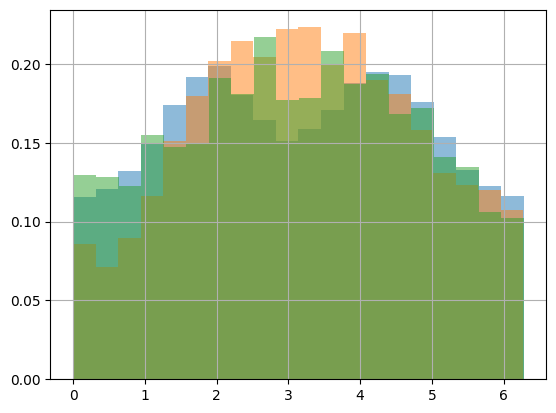

In [39]:
df_["displacement_ang"].hist(bins=20, alpha=.5, density=True)
dff["av_ang0"].hist(bins=20, alpha=.5, density=True)
dff["av_ang1"].hist(bins=20, alpha=.5, density=True)

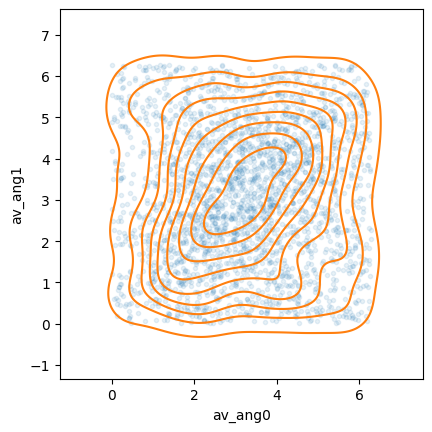

In [40]:
plt.plot(dff["av_ang0"], dff["av_ang1"], ".", alpha=.1)
sns.kdeplot(
        data=dff, x="av_ang0", y="av_ang1"
    )
plt.gca().set_aspect('equal', adjustable='box')

sa params (mu, kappa, a): [0.03526304 0.49708859 0.01808707]
Single vonMises log-likelihood: 93.70169919618164
Mixed vonMises params (mu1, k1, mu2, k2, a): [-1.01577927  1.20095857  1.06445044  1.20029786  0.01815797]
Mixed vonMises log-likelihood: 109.58187060038546


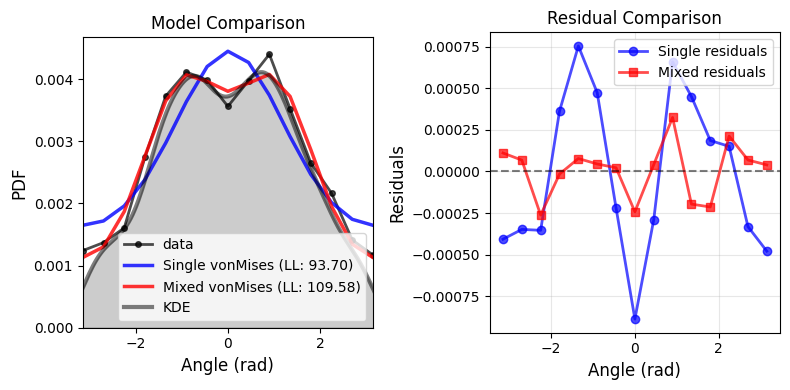

In [51]:
from scipy.optimize import curve_fit

def vonmises(x, mu, kappa, a):
    from scipy.special import i0 
    return a*np.exp(kappa*np.cos(x-mu))/(2*np.pi*i0(kappa)) 

def mixed_vonmises(x, mu1, kappa1, mu2, kappa2, a):
    return a*(.5*vonmises(x, mu1, kappa1, 1) + .5*vonmises(x, mu2, kappa2, 1))

# Fit both models to histogram p (bins_ in [0,2pi] -> shift to [-pi,pi])
x_fit = bins_ - np.pi
p_obs = p

p0_single = [-.01, 2.0, .01]
p0_mixed = [-.5, 2.0, .5, 2.0, .01]
bounds_single = ([-np.pi, 0.0, 0.0], [np.pi, 50.0, 10.0])
bounds_mixed = ([-np.pi, 0.0, -np.pi, 0.0, 0.0], [np.pi, 50.0, np.pi, 50.0, 10.0])

# Fit single vonmises
try:
    fit_single, _ = curve_fit(
        lambda xx, mu, kappa, a: vonmises(xx, mu, kappa, a),
        x_fit, p_obs, p0=p0_single, bounds=bounds_single, maxfev=10000
    )    
except Exception as e:
    print(f"Single fit failed: {e}")
    fit_single = None

# Fit mixed vonmises
try:
    fit_mix, _ = curve_fit(
        lambda xx, mu1, k1, mu2, k2, a: mixed_vonmises(xx, mu1, k1, mu2, k2, a),
        x_fit, p_obs, p0=p0_mixed, bounds=bounds_mixed, maxfev=10000
    )
except Exception as e:
    print(f"Mixed fit failed: {e}")
    fit_mix = None

# Calculate models and likelihoods
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

models_info = []

if fit_single is not None:
    model_single = vonmises(x_fit, *fit_single)
    resid_single = p_obs - model_single
    sigma2_single = np.mean(resid_single**2)
    ll_single = -0.5 * p_obs.size * (np.log(2 * np.pi * sigma2_single) + 1)
    models_info.append(("Single vonMises", fit_single, model_single, ll_single))
    print("sa params (mu, kappa, a):", fit_single)
    print("Single vonMises log-likelihood:", ll_single)

if fit_mix is not None:
    model_mix = mixed_vonmises(x_fit, *fit_mix)
    resid_mix = p_obs - model_mix
    sigma2_mix = np.mean(resid_mix**2)
    ll_mix = -0.5 * p_obs.size * (np.log(2 * np.pi * sigma2_mix) + 1)
    models_info.append(("Mixed vonMises", fit_mix, model_mix, ll_mix))
    print("Mixed vonMises params (mu1, k1, mu2, k2, a):", fit_mix)
    print("Mixed vonMises log-likelihood:", ll_mix)

# Plot data and fits
ax = axes[0]
ax.plot(x_fit, p_obs, 'o-', color='k', linewidth=2, markersize=4, label='data', alpha=0.7)
colors = ['b', 'r']
for (name, params, model, ll), color in zip(models_info, colors):
    ax.plot(x_fit, model, '-', color=color, linewidth=2.5, label=f'{name} (LL: {ll:.2f})', alpha=0.8)

# plot distribution KDE
x, y = kde_line.get_lines()[0].get_data()
ax.plot((x*np.pi/180) - np.pi, y, color='k', linewidth=3, alpha=0.5, label='KDE')
ax.fill_between((x*np.pi/180) - np.pi, y, color="k", alpha=.2)

ax.set_xlabel('Angle (rad)', fontsize=12)
ax.set_ylabel('PDF', fontsize=12)
ax.legend(fontsize=10)
ax.set_title('Model Comparison', fontsize=12)
ax.set_box_aspect(1)
ax.set_xlim([x_fit.min(), x_fit.max()])
ax.set_ylim([0, None])

# Plot residuals
ax = axes[1]
if fit_single is not None:
    resid_single = p_obs - vonmises(x_fit, *fit_single)
    ax.plot(x_fit, resid_single, 'o-', color='b', linewidth=2, label='Single residuals', alpha=0.7)
if fit_mix is not None:
    resid_mix = p_obs - mixed_vonmises(x_fit, *fit_mix)
    ax.plot(x_fit, resid_mix, 's-', color='r', linewidth=2, label='Mixed residuals', alpha=0.7)
ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('Angle (rad)', fontsize=12)
ax.set_ylabel('Residuals', fontsize=12)
ax.legend(fontsize=10)
ax.set_title('Residual Comparison', fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()


# Store results
fit_params = fit_single if fit_single is not None else fit_mix
likelihood = ll_single if fit_single is not None else ll_mix
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\tubilin displacement fit.svg")
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\bacteria fusion displacement fit.svg")

In [18]:
st

NameError: name 'st' is not defined

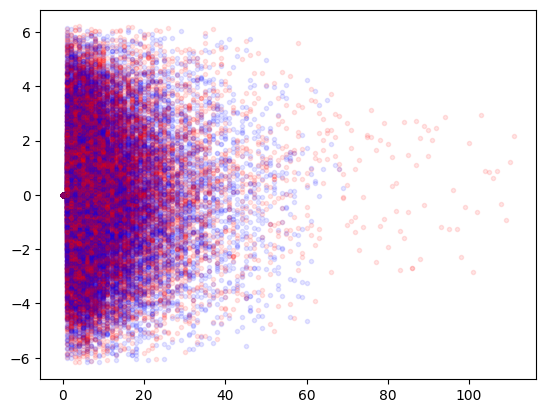

In [ ]:
for particle in df_['particle'].unique()[:]:
    
    color = "r" if df_["right"][df_.particle==particle].iloc[0] else "b"
    plt.plot(np.arange((df_.particle==particle).sum()),
             df_[df_.particle==particle]['displacement_ang'].transform(lambda x: (x-x.iloc[0])),  
             '.', alpha=.1, color=color)

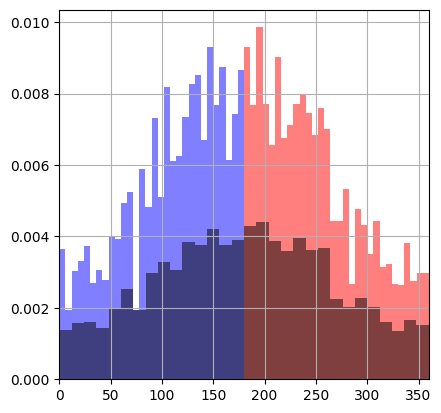

In [ ]:
(df_.av_displacement_ang[df_["right"]]*180/np.pi).hist(alpha=.5, color="r", bins=30, density=True)
(df_.av_displacement_ang[df_["left"]]*180/np.pi).hist(alpha=.5, color="b", bins=30, density=True)
(df_.av_displacement_ang*180/np.pi).hist(alpha=.5, color="k", bins=30, density=True)
plt.xlim([0,360])
plt.gca().set_box_aspect(1)

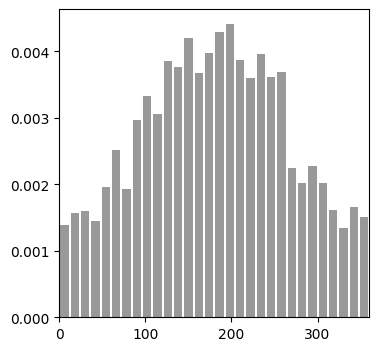

In [ ]:
fig = plt.figure(figsize=(4,4))
ax1 = plt.subplot(111)
bins_number = 30  # the [0, 360) interval will be subdivided into this
bins = np.linspace(0, 2*np.pi, bins_number+1) #* 180/np.pi

data = df_.groupby('particle')["displacement_ang"].transform(lambda a: circmean(a))
_ = ax1.hist(data*180/np.pi, bins=bins*180/np.pi, alpha=.4, density=True, rwidth=.8, color="k")
_ = ax1.set_xlim([0,360])

In [ ]:
st

NameError: name 'st' is not defined

Text(0.5, 1.0, 'Mean angular change per particle')

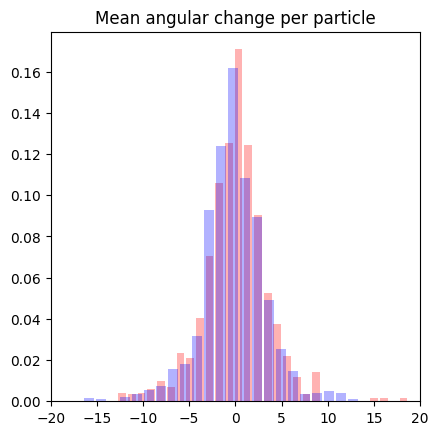

In [ ]:
# df_["ang1_change"][df_["right"]].hist(bins=30, alpha=.8, density=True, color="r", rwidth=.8)
# df_["ang1_change"][df_["left"]].hist(bins=30, alpha=.5, density=True, color="b", rwidth=.8)
# df_["ang1_change"].hist(bins=30, alpha=.3, density=True, color="k", rwidth=.8)

data = df_[df_["right"]].groupby('particle')["ang1_change"].transform(lambda angle: circmean(angle, low=-np.pi, high=np.pi))
_ = plt.hist(data.values*180/np.pi, bins=30, alpha=.3, density=True, color="r", rwidth=.8)
data = df_[df_["left"]].groupby('particle')["ang1_change"].transform(lambda angle: circmean(angle, low=-np.pi, high=np.pi))
_ = plt.hist(data.values*180/np.pi, bins=30, alpha=.3, density=True, color="b", rwidth=.8)
plt.xlim([-20,20])
plt.gca().set_box_aspect(1)
plt.title("Mean angular change per particle")

In [ ]:
st

NameError: name 'st' is not defined

In [ ]:
image_list[dfs_.frame.iloc[0]+frame_shift:dfs_.frame.iloc[-1]+frame_shift]

['C:\\Users\\victo\\OneDrive - BGU\\HBEC\\s2(120-1057)\\Raw\\Trans__361.tif',
 'C:\\Users\\victo\\OneDrive - BGU\\HBEC\\s2(120-1057)\\Raw\\Trans__362.tif',
 'C:\\Users\\victo\\OneDrive - BGU\\HBEC\\s2(120-1057)\\Raw\\Trans__363.tif',
 'C:\\Users\\victo\\OneDrive - BGU\\HBEC\\s2(120-1057)\\Raw\\Trans__364.tif',
 'C:\\Users\\victo\\OneDrive - BGU\\HBEC\\s2(120-1057)\\Raw\\Trans__365.tif',
 'C:\\Users\\victo\\OneDrive - BGU\\HBEC\\s2(120-1057)\\Raw\\Trans__366.tif',
 'C:\\Users\\victo\\OneDrive - BGU\\HBEC\\s2(120-1057)\\Raw\\Trans__367.tif',
 'C:\\Users\\victo\\OneDrive - BGU\\HBEC\\s2(120-1057)\\Raw\\Trans__368.tif',
 'C:\\Users\\victo\\OneDrive - BGU\\HBEC\\s2(120-1057)\\Raw\\Trans__369.tif']

In [ ]:
dfs_

,Unnamed: 0,charge,x,y,x_img1,y_img1,ang1,ang2,ang3,frame,particle,POSITION_T,ang1_change,mean_ang1,displacement_ang,right,left,av_displacement_ang
40556,40556,0.5,696,131,696,131,-2.953097,NaN,NaN,201,7718,201,0.000000,3.330088,4.987541,False,True,3.097733
40558,40558,0.5,1919,100,1919,100,0.125664,NaN,NaN,201,7566,201,0.062832,0.094248,1.587030,False,True,1.830171
40561,40561,0.5,1932,430,1932,430,-3.078761,NaN,NaN,201,8064,201,0.062832,3.173009,4.300786,True,False,3.507607
40562,40562,0.5,668,446,668,446,-1.633628,NaN,NaN,201,7878,201,-0.062832,4.680973,5.238868,False,True,0.073947
40565,40565,0.5,511,172,511,172,-1.130973,NaN,NaN,201,8069,201,-0.188496,5.246460,2.618628,False,True,1.324009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42442,42442,0.5,945,44,945,44,1.130973,NaN,NaN,210,8137,210,0.000000,1.130973,4.366814,True,False,3.999723
42443,42443,0.5,1140,54,1140,54,1.822124,NaN,NaN,210,6963,210,0.062832,1.790708,4.182762,True,False,5.396858
42445,42445,0.5,1907,112,1907,112,0.125664,NaN,NaN,210,7566,210,0.062832,0.094248,3.801327,False,True,1.830171
42446,42446,0.5,1769,119,1769,119,-0.376991,NaN,NaN,210,8219,210,-1.005310,0.125664,0.085534,False,True,2.016800


In [ ]:
Cells = False
if Cells:
    #  Cell flow fields
    image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\HBEC\s2(120-1057)\Raw\*.tif")
    start_frame = 200
    frame_shift = 160
    box = 370
    total_frames = 11
else:
    #  Bacteria flow fields
    image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\BEER\6\*.tif")
    start_frame = 0
    frame_shift = 0
    box = 250
    total_frames = 350

image_list = natsorted(image_list, key=lambda y: y.lower())
dfs_ = df_[(df_.frame>start_frame)&(df_.frame<start_frame+total_frames)].copy()

first_frame = int(frame_shift + start_frame + df_.frame.unique()[0])
last_frame = int(first_frame + total_frames) #len(image_list)
frames = np.arange(dfs_.frame.iloc[0], dfs_.frame.iloc[-1]) 

flow_sigma = 15 #15

images = [cv2.imread(img, cv2.IMREAD_UNCHANGED) for img in image_list[dfs_.frame.iloc[0]+frame_shift:dfs_.frame.iloc[-1]+frame_shift]]


u_v_count = Parallel(n_jobs=5)(delayed(defect_flow_frame_average_with_edge)(
    img1, img2, 
    # dfs_[dfs_['frame']==frame_num][['x','y','ang1']].rename(columns={"x":"xp", "y":"yp", "ang1":"angp1"}),
    # dfs_[(dfs_['frame']==frame_num)&(dfs_['left'])][['x','y','ang1']].rename(columns={"x":"xp", "y":"yp", "ang1":"angp1"}),
    dfs_[(dfs_['frame']==frame_num)&(dfs_['right'])][['x','y','ang1']].rename(columns={"x":"xp", "y":"yp", "ang1":"angp1"}),
    defect_type="all", 
    box=(int(box),int(box)),
    sigma=flow_sigma,
    ) for frame_num,img1,img2 in zip(frames, images[:-1], images[1:]))

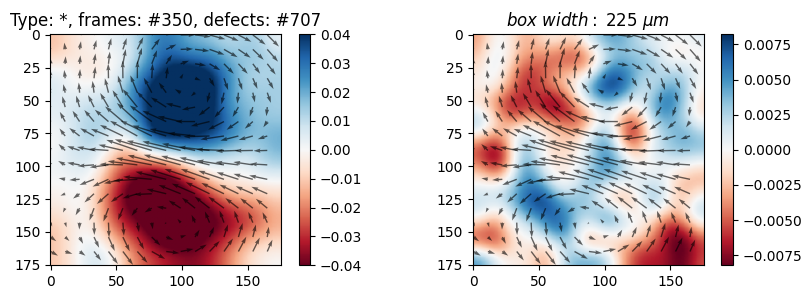

In [ ]:
%matplotlib inline
u, v, count = [], [], []
for q in u_v_count:
    if q:
        u.append(q[0])
        v.append(q[1])
        count.append(q[2])
u = np.array(u)
v = np.array(v)
count = np.array(count)  

n, m = 0,-1 
u_up = np.average(u[count!= 0][n:m,:,:], axis=0, weights=count[count!= 0][n:m])
v_up = np.average(v[count!= 0][n:m,:,:], axis=0, weights=count[count!= 0][n:m])

filt = 10
step = u_up.shape[0]//15 # 20-bacteria # 15-cells
vscale = 10 # 10-bacteria # 5-cells

fig, axs = plt.subplots(1,2, figsize=(10,3))
# for ax in axs.ravel(): ax.axis('off')
ax1, ax2 = axs.ravel()

field = np.stack((u_up, v_up), axis=-1)
y, x = np.mgrid[0:u_up.shape[0], 0:u_up.shape[1]] 
vorticity = gaussian_filter(curl_npgrad(field), sigma=filt)
vort_scale = .04 #0.019 #np.max([np.max(vorticity), -np.min(vorticity)]) # .05 #
c1 = ax1.imshow(vorticity, cmap='RdBu', vmin=-vort_scale, vmax=vort_scale)
ax1.quiver(x[::step, ::step], y[::step, ::step], 
          u_up[::step, ::step], -v_up[::step, ::step],  color='k',
          width=.006, scale=vscale, alpha=.6)
ax1.set_title("Type: %1s, frames: #%1d, defects: #%1d" % ("*", last_frame-first_frame, np.sum(count)))
fig.colorbar(c1)

divergence = gaussian_filter(divergence_npgrad(field), sigma=filt)
div_scale = np.max([np.max(divergence), -np.min(divergence)])
c2 = ax2.imshow(divergence, cmap='RdBu', vmin=-div_scale, vmax=div_scale)
ax2.quiver(x[::step, ::step], y[::step, ::step], 
          u_up[::step, ::step], -v_up[::step, ::step],  color='k',
          width=.006, scale=vscale, alpha=.6)
ax2.set_title("$box ~width: ~%1d ~\mu m$" % (box * .9))
fig.colorbar(c2)

type_str = "cells" if Cells else "bacteria"
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images/"+ type_str+" flow fields_R.svg")

In [ ]:
frame2sec = 1/50
1/frame2sec*vorticity.mean(), 1/frame2sec*vorticity.std(), vorticity.mean(), vorticity.std()

(np.float64(0.03357882839026161),
 np.float64(1.2884655803576626),
 np.float64(0.0006715765678052323),
 np.float64(0.02576931160715325))

In [ ]:
.04*50, 0.019*12, 

(2.0, 0.22799999999999998)

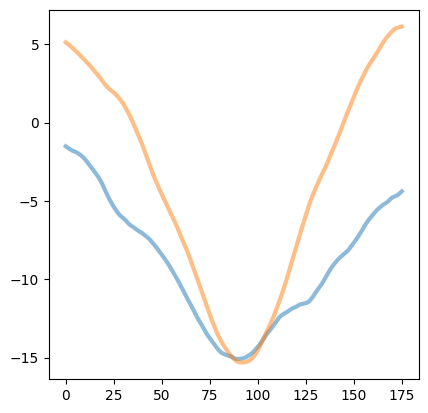

In [ ]:
# bacteria
px_frame_to_um_sec = 150/900 / (1/50)  # um per pixel per second
# Cells
px_frame_to_um_sec = 0.74 / (1/12)  # um per pixel per second
dd = 5
midlle = u_up.shape[1]//2
plt.plot(px_frame_to_um_sec * u_up[midlle-dd:midlle+dd,:].mean(axis=0), linewidth=3, alpha=.5)
plt.plot(px_frame_to_um_sec * u_up[:,midlle-dd:midlle+dd].mean(axis=1), linewidth=3, alpha=.5)
plt.gca().set_box_aspect(1)

In [ ]:
st

NameError: name 'st' is not defined

# Mean Flow

In [ ]:
%matplotlib qt
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(6,6))


# ax1.imshow(np.zeros_like(img, dtype=np.float32), cmap="gray")
# "E:\C2C12 and RPE in 6 well\15min5x\_1\Pos18"
image_list = glob.glob(r"E:\HT1080\c3_6well_5min_10x\_2\Pos10\*.tif")
# image_list = glob.glob(r"E:\C2C12 and RPE in 6 well\15min5x\_1\Pos23\*.tif")
image_list = natsorted(image_list, key=lambda y: y.lower())

img = imread(image_list[55])
img_clahe = clahe.apply(img)
ori, plusR, minR =  analyze_defects(img_clahe, sigma=21)

fig, ax1 = plt.subplots()
ax1.axis('off')
ax1.imshow(255-img_clahe, cmap="gray")  

s = 25
y, x = np.mgrid[0:img.shape[0], 0:img.shape[1]]
ax1.quiver(x[::s,::s], y[::s,::s],
    np.cos(ori)[::s,::s], np.sin(ori)[::s,::s], np.arctan2(np.sin(ori), np.cos(ori))[::s,::s],
    headaxislength=0, headwidth=0, headlength=0, width=.005,
    scale=35, pivot='mid', alpha=0.5, cmap='hsv')


alpha_half, scale_half = .8, 20    
ax1.plot(plusR['x'], plusR['y'],'ro',markersize=8, alpha=alpha_half)
ax1.quiver(plusR['x'], plusR['y'], 
    np.cos(plusR['ang1']), -np.sin(plusR['ang1']), 
    headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

ax1.plot(minR['x'], minR['y'],'wo',markersize=6, alpha=alpha_half)
for j in range(3):
    ax1.quiver(minR['x'], minR['y'], 
        np.cos(minR['ang'+str(j+1)]), -np.sin(minR['ang'+str(j+1)]), 
        headaxislength=0, headwidth=0, headlength=0, color='w', scale=scale_half, alpha=alpha_half)



plt.gca().set_box_aspect(1)


In [ ]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(6,6))

fov_lst = []#[1,2,7,8, 13,14,20,21, 25,26,33,34]
fov_lst = np.arange(1,36)
image_list = glob.glob(r"D:\HT1080\c3_6well_5min_10x\_2\Pos"+str(fov_lst[10])+"\*.tif")
# image_list = glob.glob(r"E:\C2C12 and RPE in 6 well\15min5x\_1\Pos23\*.tif")
image_list = natsorted(image_list, key=lambda y: y.lower())


fig, axs = plt.subplots(1,2, figsize=(10,5))
img_path = image_list[-1]
for ax,img_path in zip(axs, [image_list[4], image_list[-1]]):
    img = imread(img_path)
    img_clahe = clahe.apply(img)

    ax.imshow(255-img_clahe, cmap="gray")  
ax.set_title(os.path.basename(img_path))

Text(0.5, 1.0, 'img_channel000_position011_time000000436_z000.tif')

In [ ]:

image_list = glob.glob(folder+"/Pos*/*.tif")
natsorted(image_list, key=lambda y: y.lower())[-1]

'E:\\HT1080\\c3_6well_5min_10x\\_4\\Pos36\\img_channel000_position036_time000000287_z000.tif'

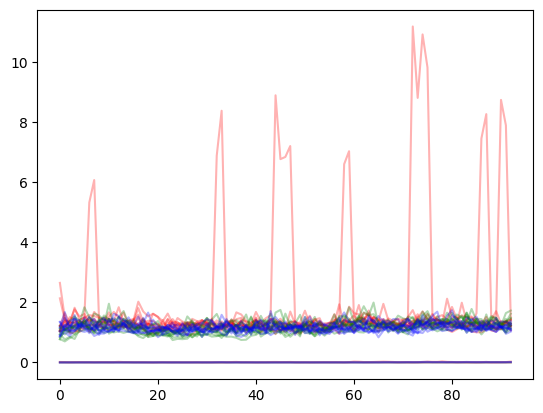

In [ ]:
def u_vel(im1,im2):
    return cv2.calcOpticalFlowFarneback(im1,im2, 
        None, 0.5, 3, winsize=10, iterations=3, poly_n=5, poly_sigma=1.2, flags=0)#.astype(np.float16)

def get_vrms(u,v):
    u = u-u.mean()
    v = v-v.mean()
    return ((u**2 + v**2)**.5).mean()

PLOT = True
# folder = r"E:\HT1080\c3_6well_5min_10x\_2"
folder = r"D:\C2C12 With C3 in 6 well x5 15min\_4"
frame_num = -2
# fov_lst = [6,7,8,10, 13,14,20,21, 25,26,33,34]
fov_lst = np.arange(0,34)
df = pd.DataFrame()

colors = ["r","r","r","r",  "g","g","g","g", "b","b","b","b"]
for i,fov in enumerate(fov_lst):
    image_list = glob.glob(folder+"/Pos"+str(fov)+"\*.tif")
    image_list = natsorted(image_list, key=lambda y: y.lower())

    
    uv_vel_list = Parallel(n_jobs=5)(
        delayed(u_vel)(
            cv2.imread(img1)[...,0],cv2.imread(img2)[...,0]) for (img1,img2) in zip(image_list[:frame_num-1],image_list[1:frame_num]
                        ))
    vrms = [get_vrms(uv[0],uv[1]) for uv in uv_vel_list]
    std = [(uv[0]-uv[0].mean()).std() for uv in uv_vel_list]
    time = np.arange(len(vrms))

    if PLOT:
        if int(fov)<=11: color = "r"
        elif int(fov)>11 and int(fov)<=22: color = "g"
        else: color = "b"        
        plt.plot(time, vrms, color=color, alpha=.3, label="FOV: #%1d|%.3f" % (fov, np.median(vrms)))

    progressBar(i, len(fov_lst))

    df[str(fov)] = vrms
    df[str(fov)+"_std"] = std
    # break
        
# if PLOT: plt.legend()

# df.to_csv(folder+"/_vrms3.csv")

In [ ]:
plt.plot(time, vrms, alpha=.3, label="FOV: #%1d|%.3f" % (fov, np.median(vrms)))

In [ ]:
df.to_csv(folder+"/_vrms3.csv")

Text(0.5, 1.0, 'E:\\HT1080\\c3_6well_5min_10x\\_5')

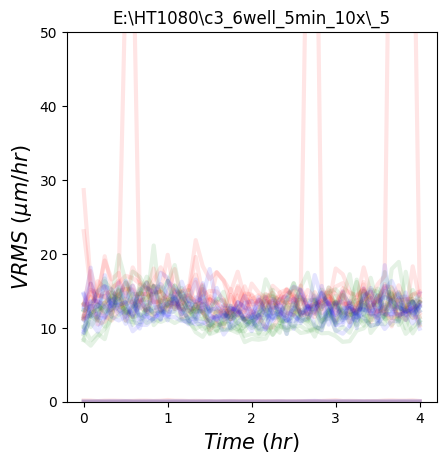

In [ ]:
%matplotlib inline
folder = r"E:\HT1080\c3_6well_5min_10x\_5"
df1 = df#pd.read_csv(folder+"/_vrms3.csv")
exclude_list = [1,2,3,4,5,6,12,18,24,30]
fov_lst = [col for col in df1.keys() if 'std' not in col and col.isdigit() and int(col) not in exclude_list]
fov_lst = np.arange(0,34)

plt.figure()
time = np.arange(len(df1))/12
for i,fov in enumerate(fov_lst[:]):
    if int(fov)<=11: color = "r"
    elif int(fov)>11 and int(fov)<=22: color = "g"
    else: color = "b"

    plt.plot(time, df1[str(fov)] * .9*12, label=str(fov), color=color, alpha=.1, linewidth=3)
    # plt.plot(time, df1[str(fov)] * .9*12, label=str(fov), alpha=.3, linewidth=3)

# plt.legend()
plt.title("VRMS")
plt.xlabel("$Time ~(hr)$", fontsize=15)
plt.ylabel("$VRMS ~(\mu m/hr)$", fontsize=15)
plt.ylim(0, 50)
plt.gca().set_box_aspect(1)
plt.title(folder)

In [ ]:
df = pd.read_csv(r"E:\HT1080\c3_6well_5min_10x\_2\_vrms1.csv")

C:\Users\victo\AppData\Local\Temp\ipykernel_25016\2152427929.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FOV', y='VRMS', data=df_melted, palette=colors)


(0.0, 60.0)

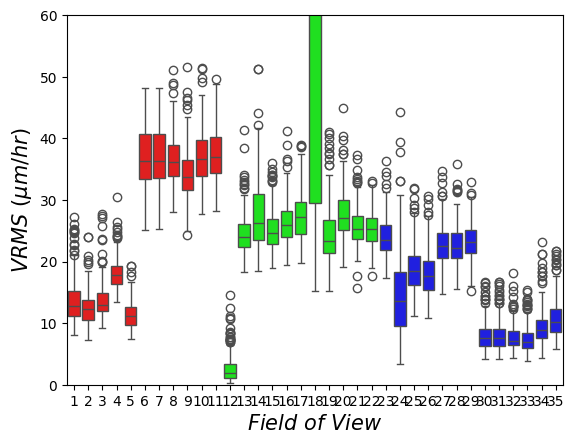

In [ ]:
%matplotlib inline
import seaborn as sns
folder = r"D:\HT1080\c3_6well_5min_10x\_5"
df1 = pd.read_csv(folder+"/_vrms3.csv")
exclude_list = []#[1,2,3,4,5,12,18,24,30]
fov_lst = [col for col in df1.keys() if 'std' not in col and col.isdigit() and int(col) not in exclude_list]

df_selected = df1[[str(fov) for fov in fov_lst]]
df_melted = df_selected.melt(var_name='FOV', value_name='VRMS')

# Set colors based on the condition
colors = [(1,0,0, 0.5) if int(fov) <= 11 else (0,1,0, 0.5) if int(fov) <= 22 else (0,0,1, 0.5) for fov in fov_lst]

df_melted['VRMS'] = df_melted['VRMS'] * .9*12

sns.boxplot(x='FOV', y='VRMS', data=df_melted, palette=colors)
plt.xlabel("$Field ~of ~View$", fontsize=15)
plt.ylabel("$VRMS ~(\mu m/hr)$", fontsize=15)
plt.ylim(0, 60)


In [ ]:
def u_vel(im1,im2):
    return cv2.calcOpticalFlowFarneback(im1,im2, 
        None, 0.5, 3, winsize=15, iterations=3, poly_n=5, poly_sigma=1.2, flags=0)#.astype(np.float16)

frame_num = -2
# uv_vel_list = [u_vel(cv2.imread(img1)[:,900:,0],cv2.imread(img2)[:,900:,0]) for (img1,img2) in zip(image_list[:frame_num-1],image_list[1:frame_num])]
uv_vel_list = Parallel(n_jobs=5)(delayed(u_vel)(cv2.imread(img1)[...,0],cv2.imread(img2)[...,0]) for (img1,img2) in zip(image_list[:frame_num-1],image_list[1:frame_num]))


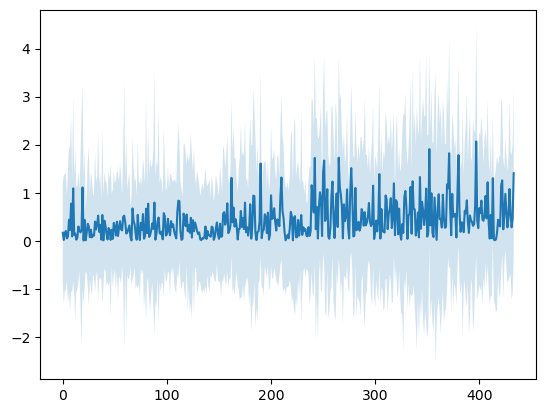

In [ ]:
%matplotlib inline
vrms = [(uv[0].mean()**2 + uv[1].mean()**2)**.5 for uv in uv_vel_list]
std = [uv[0].std() for uv in uv_vel_list]
time = np.arange(len(vrms))
plt.plot(time, vrms)
plt.fill_between(time, np.array(vrms)-np.array(std), np.array(vrms)+np.array(std), alpha=.2)

In [ ]:
%matplotlib qt
n = 9
img1 = cv2.imread(image_list[n])[:,:,0]
img2 = cv2.imread(image_list[n+1])[:,:,0]
flow = cv2.calcOpticalFlowFarneback(img1,img2, None, 0.5, 3, 
    winsize=10, iterations=3, poly_n=5, poly_sigma=1.2, flags=0) 
flow[..., 0] = gaussian_filter(flow[..., 0], sigma=5)
flow[..., 1] = gaussian_filter(flow[..., 1], sigma=5)

step = 10
fig, ax1 = plt.subplots(1,1)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(6,6))
img_clahe = clahe.apply(img1)
ax1.imshow(255-img_clahe, cmap="gray")

x = np.arange(0, flow.shape[1], step, dtype=np.int16)
y = np.arange(0, flow.shape[0], step, dtype=np.int16)
ax1.quiver(x,y, 
        flow[::step, ::step, 0], -flow[::step, ::step, 1], #np.arctan2(flow[:,:, 1], flow[:,:,  0])[::step,::step],
        color="red", scale=50, alpha=.6, cmap='hsv', width=.003)

fig, ax2 = plt.subplots(1,1,  figsize=(4,4))
# ax2.hist(np.concatenate(v)/(i+1), 60, alpha=.3, rwidth=.9, density=True, label="v")
# ax2.hist(np.concatenate(u)/(i+1),60, alpha=.8, rwidth=.8, density=True, label="u")
ax2.hist(flow[..., 1].ravel(), 60, alpha=.3, rwidth=.9, density=True, label="v")
ax2.hist(flow[..., 0].ravel(),60, alpha=.8, rwidth=.8, density=True, label="u")
plt.legend(loc='upper right', fontsize=14)

vrms = (flow[..., 0].mean()**2 + flow[..., 1].mean()**2)**.5
print(vrms.mean())

0.91050833
